In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../data/raw/survey.csv")
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


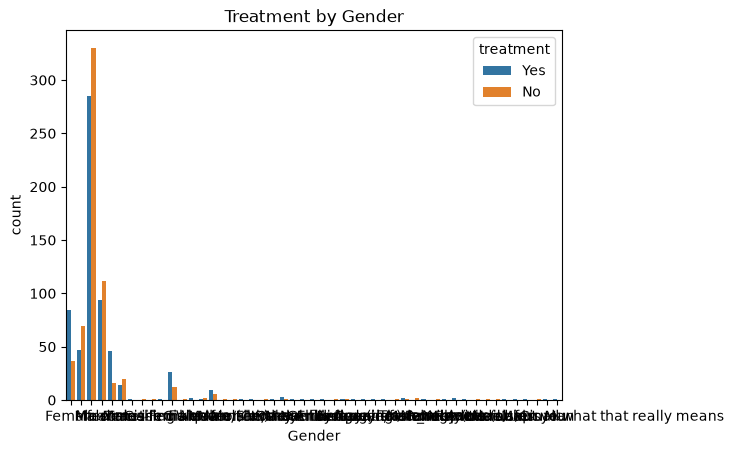

In [5]:
sns.countplot(data=df, x='Gender', hue='treatment')
plt.title("Treatment by Gender")
plt.show()

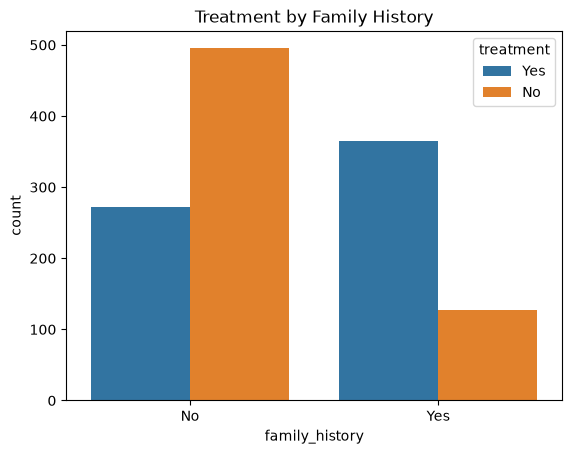

In [6]:
sns.countplot(data=df, x='family_history', hue='treatment')
plt.title("Treatment by Family History")
plt.show()

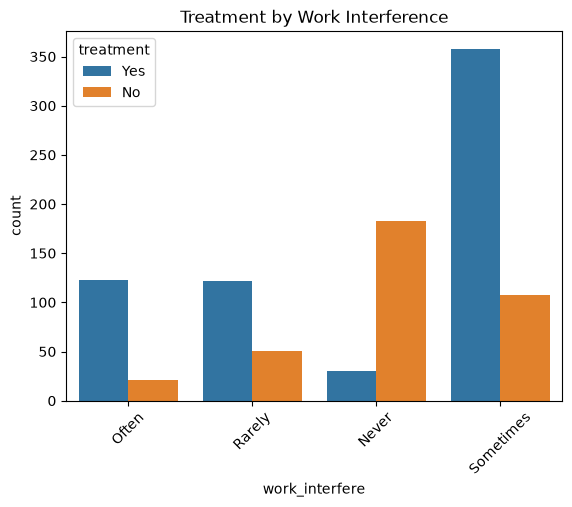

In [7]:
sns.countplot(data=df, x='work_interfere', hue='treatment')
plt.title("Treatment by Work Interference")
plt.xticks(rotation=45)
plt.show()

In [8]:
df['age_group'] = pd.cut(
    df['Age'],
    bins=[15, 25, 35, 45, 55, 75],
    labels=['15-25', '26-35', '36-45', '46-55', '55+']
)

In [9]:
df['has_support'] = (
    (df['benefits'] == 'Yes').astype(int) +
    (df['wellness_program'] == 'Yes').astype(int) +
    (df['seek_help'] == 'Yes').astype(int)
)

In [10]:
df['disclosure_comfort'] = (
    (df['coworkers'] == 'Yes').astype(int) +
    (df['supervisor'] == 'Yes').astype(int)
)

In [11]:
df['treatment'] = df['treatment'].map({'No': 0, 'Yes': 1})

In [12]:
X = df.drop('treatment', axis=1)
y = df['treatment']

X = pd.get_dummies(X, drop_first=True)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)